In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pt
import seaborn as sns
import sqlite3

In [2]:
conn = sqlite3.connect("customer_churn.db")
sql_query = """
        SELECT name
        FROM sqlite_master
        WHERE type = 'table';
"""

tables = pd.read_sql(sql_query,conn)

for table_name in tables['name']:
  df = pd.read_sql(f"SELECT * FROM {table_name}",conn)
  globals()[f"df_{table_name}"] = df
  print(f"Created dataframe: df_{table_name}")

conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [3]:
conn = sqlite3.connect("customer_churn.db")

for table_name in tables['name']:
  print(f"\n Table Name: {table_name}")

  column_query = f"PRAGMA table_info({table_name});"
  columns = pd.read_sql(column_query,conn)
  print("Column:")
  print(columns['name'].tolist())


conn.close()


 Table Name: db_customer
Column:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

 Table Name: db_subscription
Column:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

 Table Name: db_support
Column:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [4]:
print(tables)

              name
0      db_customer
1  db_subscription
2       db_support


In [5]:
#Data cleaning

In [6]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [7]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [8]:
# change col - name
# drop columns - interest and pincode
# change datatype - dob
# data standardization - gender
# fix missing values


In [9]:
df_db_customer.rename(columns = {'name': 'customer_name'},inplace=True)

In [10]:
df_db_customer.head()

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [11]:
df_db_customer.drop(['interests','pincode'],axis=1,inplace=True)

In [12]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [13]:
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [14]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [15]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     object        
 1   customer_name  21 non-null     object        
 2   country        18 non-null     object        
 3   state          21 non-null     object        
 4   gender         21 non-null     object        
 5   dob            21 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 1.1+ KB


In [16]:
df_db_customer['gender'].unique()

array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [17]:
df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'},inplace=True)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_25036\3934674328.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'},inplace=True)


In [18]:
df_db_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [19]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [20]:
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [21]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [22]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,India,Delhi,Female,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,Nepal,Kathmandu,Female,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [23]:
df_db_subscription

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,None,None,17.99,720,22
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,None,None,22.99,1840,5
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,None,None,13.99,240,34
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,None,None,6.99,335,41


In [24]:
df_db_subscription['subscription_type'] = df_db_subscription['subscription_type'].replace({'Refferal' : 'Referral'})

In [25]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [26]:
date_col = ['subscription_start_date','renewal_date','cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)

In [27]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [28]:
df_db_support

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None
5,0017-IUDMW,2024-04-10 00:00:00,Y,25,None,None
6,0019-EFAEP,2024-09-27 00:00:00,Y,30,None,None
7,0022-TCJCI,2024-09-13 00:00:00,Y,10,None,None
8,0022-TCJCI,2024-09-14 00:00:00,N,90,None,received refund


In [29]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [30]:
df_db_support.drop(['col_1','comment'],axis=1,inplace=True)

In [31]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [32]:
#Feature Engineering

df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [33]:
df_db_subscription

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Referral,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Referral,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,None,17.99,720,22,0
6,0013-SMEOE,2021-09-30,Referral,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,None,22.99,1840,5,0
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,None,13.99,240,34,0
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,None,6.99,335,41,0


In [34]:
df = (df_db_subscription
  .merge(df_db_customer,on = 'customerid',how = 'left')
  .merge(df_db_support,on = 'customerid',how = 'left'))

In [35]:
df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Referral,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN
5,0013-EXCHZ,2023-01-05,Referral,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0
6,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,None,17.99,720,22,0,durga,India,Delhi,Female,1988-12-10,2025-03-18,N,90.0
7,0013-SMEOE,2021-09-30,Referral,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1,mina,India,Meghalaya,Female,1976-09-21,2024-11-01,N,30.0
8,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,None,22.99,1840,5,0,madan,India,Rajasthan,Male,1999-03-14,NaT,NaN,NaN
9,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,None,13.99,240,34,0,maya,Nepal,Kathmandu,Female,1985-07-07,NaT,NaN,NaN


In [36]:
df.shape

(23, 20)

In [37]:
# Aggregate support tickets per customer instead of keeping only the last one
support_agg = df_db_support.groupby('customerid').agg(
    complaint_count=('customerid', 'count'),
    any_escalation=('escalations', lambda x: 'Y' if (x == 'Y').any() else 'N'),
    min_csat=('csat_score', 'min'),
    last_complaint_date=('complaint_date', 'max')
).reset_index()

support_agg.head()

,customerid,complaint_count,any_escalation,min_csat,last_complaint_date
0,0003-MKNFE,2,Y,10,2024-08-28
1,0013-EXCHZ,1,Y,20,2024-01-20
2,0013-MHZWF,1,N,90,2025-03-18
3,0013-SMEOE,1,N,30,2024-11-01
4,0017-IUDMW,1,Y,25,2024-04-10


In [38]:
df = (df_db_subscription
  .merge(df_db_customer, on='customerid', how='left')
  .merge(support_agg, on='customerid', how='left'))

df['complaint_count'] = df['complaint_count'].fillna(0)

In [39]:
df_db_support.shape

(9, 4)

In [40]:
df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_count,any_escalation,min_csat,last_complaint_date
0,0002-ORFBO,2021-03-15,Referral,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,0.0,NaN,NaN,NaT
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2.0,Y,10.0,2024-08-28
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,0.0,NaN,NaN,NaT
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,0.0,NaN,NaN,NaT
4,0013-EXCHZ,2023-01-05,Referral,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,1.0,Y,20.0,2024-01-20
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,None,17.99,720,...,0,durga,India,Delhi,Female,1988-12-10,1.0,N,90.0,2025-03-18
6,0013-SMEOE,2021-09-30,Referral,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,1,mina,India,Meghalaya,Female,1976-09-21,1.0,N,30.0,2024-11-01
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,None,22.99,1840,...,0,madan,India,Rajasthan,Male,1999-03-14,0.0,NaN,NaN,NaT
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,None,13.99,240,...,0,maya,Nepal,Kathmandu,Female,1985-07-07,0.0,NaN,NaN,NaT
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,None,6.99,335,...,0,arjun,Nepal,Kathmandu,Male,1993-10-29,0.0,NaN,NaN,NaT


In [41]:
df.shape

(21, 21)

In [42]:
df.to_csv('exported_churn_data',index=False)

In [43]:
#Data Analysis

In [44]:
#1. Churn Rate

In [45]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_count', 'any_escalation', 'min_csat', 'last_complaint_date'],
      dtype='object')

In [46]:
churn_rate = df['churn_flag'].mean()*100
print('Churn Rate :', round(churn_rate,2), '%')

Churn Rate : 28.57 %


In [47]:
#2. Retension
retension = 100-churn_rate
print('Retension :',round(retension,2),'%')

Retension : 71.43 %


In [48]:
#3 Churn By Plan type
df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct')

,plan_type,churn_rate_pct
0,Basic,60.00
1,Premium,14.29
2,Standard,22.22


In [49]:
#4 a. Churn by state + sum(revenue) & count of users
#4 b. churn by subscription type

In [50]:
churn_by_state =  df.groupby('state')['churn_flag'].mean().mul(100).round(2).reset_index()
churn_by_state

,state,churn_flag
0,Delhi,25.00
1,Karnataka,100.00
2,Kathmandu,0.00
3,Maharashtra,0.00
4,Meghalaya,66.67
5,Nagaland,0.00
6,Rajasthan,0.00
7,Telangana,50.00
8,Uttar Pradesh,0.00


In [51]:
df.groupby('state').agg(
    total_revenue=('monthly_charges', 'sum'),
    total_users=('customerid', 'count')
).reset_index()

,state,total_revenue,total_users
0,Delhi,52.96,4
1,Karnataka,20.98,2
2,Kathmandu,20.98,2
3,Maharashtra,50.97,3
4,Meghalaya,42.97,3
5,Nagaland,22.99,1
6,Rajasthan,36.98,2
7,Telangana,30.98,2
8,Uttar Pradesh,115.98,2


In [52]:
df.groupby('subscription_type')['churn_flag'].mean().mul(100).round(2).reset_index()

,subscription_type,churn_flag
0,Organic,0.00
1,Paid,16.67
2,Referral,83.33


In [53]:
#5. ARPU - Avg Rev Per User
arpu = df['monthly_charges'].mean()
arpu

np.float64(18.847142857142856)

In [54]:
#6. Avg Customer Tenure
today = pd.Timestamp('2026-09-20')
df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date']-df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days

)
avg_tenure = df['tenure_days'].mean()
print('Avg Tenure (Days) = ',round(avg_tenure))

Avg Tenure (Days) =  1543


In [55]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_count', 'any_escalation', 'min_csat', 'last_complaint_date',
       'tenure_days'],
      dtype='object')

In [56]:
df.head(5)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_count,any_escalation,min_csat,last_complaint_date,tenure_days
0,0002-ORFBO,2021-03-15,Referral,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,0.0,NaN,NaN,NaT,2015.0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2.0,Y,10.0,2024-08-28,1501.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,0.0,NaN,NaN,NaT,1400.0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,0.0,NaN,NaN,NaT,2690.0
4,0013-EXCHZ,2023-01-05,Referral,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,mira,India,Delhi,Female,1990-05-05,1.0,Y,20.0,2024-01-20,419.0


In [57]:
df[['churn_flag','cancellation_date']]

,churn_flag,cancellation_date
0,0,NaT
1,1,2024-09-10
2,0,NaT
3,0,NaT
4,1,2024-02-28
5,0,NaT
6,1,2024-11-15
7,0,NaT
8,0,NaT
9,0,NaT


In [58]:
#Revenue at Risk - revenuie lost from churned user
rev_at_risk = np.where(df['cancellation_date'].notna(),df['monthly_charges'],0)
rev_at_risk.sum()


np.float64(73.94)

In [59]:
#8. Escalation Rate
escalation_rate = (df['any_escalation']=='Y').mean()*100
print('Escalation Rate : ',round(escalation_rate,2),'%')

Escalation Rate :  23.81 %


In [60]:
print(df.columns.tolist())

['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score', 'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob', 'complaint_count', 'any_escalation', 'min_csat', 'last_complaint_date', 'tenure_days']


In [61]:
#9. Avg Complaints per customer
avg_com = df['complaint_count'].sum() / df['customerid'].nunique()

print('Avg Complaints Per User = ',round(avg_com,2))

Avg Complaints Per User =  0.43


In [62]:
#10. Correlation Escalation vs churn

df['any_escalation'] = np.where(df['any_escalation']=='Y',1,0)
corr_df = df[['any_escalation','churn_flag']].dropna()

correlation = corr_df['any_escalation'].corr(df['churn_flag'])
print('Correlation Between escalation vs churn : ',round(correlation,2))

Correlation Between escalation vs churn :  0.88


In [63]:
#11. Churn Risk - create a column using existing col
conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
]

choices = ['Low','Medium','High']

df['churn_risk'] = np.select(conditions,choices,default = 'unknown')

In [64]:
df[['churn_score','churn_risk']].tail()

,churn_score,churn_risk
16,62,Medium
17,27,Low
18,99,High
19,7,Low
20,47,Low


In [65]:
#Visualization using Matplotlib

In [66]:
df_visuals = df.copy()

In [67]:
df_visuals.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_count,any_escalation,min_csat,last_complaint_date,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Referral,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,India,Maharashtra,Male,1982-04-12,0.0,0,NaN,NaT,2015.0,Low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2.0,1,10.0,2024-08-28,1501.0,High
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,India,Delhi,Female,1978-02-15,0.0,0,NaN,NaT,1400.0,Low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,India,Nagaland,Male,2001-08-30,0.0,0,NaN,NaT,2690.0,Low
4,0013-EXCHZ,2023-01-05,Referral,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,1.0,1,20.0,2024-01-20,419.0,High


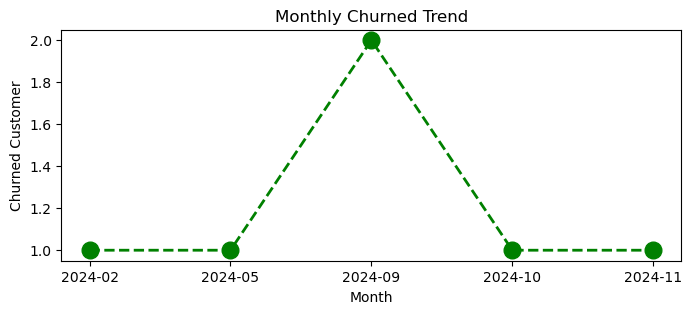

In [68]:
#Monthly Churn Trend(Time Series KPI)

df_visuals['cancellation_month'] = df_visuals['cancellation_date'].dt.to_period('M')

churn_trend = df_visuals[df_visuals['churn_flag']==1].groupby('cancellation_month').size()

pt.figure(figsize=(8,3))
pt.plot(churn_trend.index.astype(str),churn_trend.values,color='green',marker='o',linestyle='dashed',linewidth=2,markersize=12)

pt.title('Monthly Churned Trend')
pt.xlabel('Month')
pt.ylabel('Churned Customer')
pt.show()

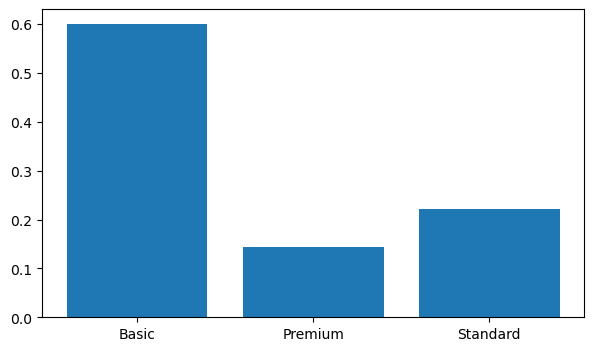

In [69]:
#Churn by plan type
churn_plan = df_visuals.groupby('plan_type')['churn_flag'].mean()

pt.figure(figsize=(7,4))
pt.bar(churn_plan.index,churn_plan.values)
pt.show()

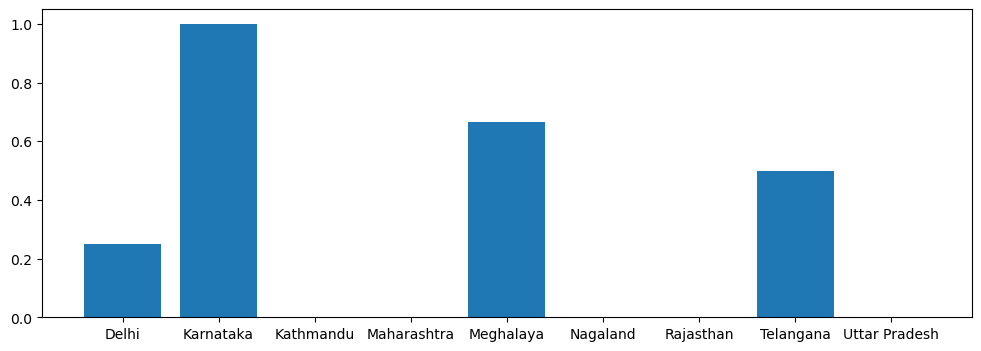

In [70]:
#churn by state
churn_plan = df_visuals.groupby('state')['churn_flag'].mean()

pt.figure(figsize=(12,4))
pt.bar(churn_plan.index,churn_plan.values)
pt.show()

In [71]:
#encoding - converts the str to numeric so that we can find corr between features
df_visuals.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_count', 'any_escalation', 'min_csat', 'last_complaint_date',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [72]:
df_visuals[['plan_type', 'contract_type','churn_score',
       'churn_flag', 'churn_risk', 'any_escalation']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,any_escalation
0,Standard,Annual,12,0,Low,0
1,Premium,Annual,91,1,High,1
2,Basic,Monthly,34,0,Low,0
3,Premium,Annual,8,0,Low,0
4,Standard,Monthly,88,1,High,1


In [73]:
import warnings
warnings.filterwarnings("ignore")

In [74]:
#Incorrect method of encoding -
df_encoded = df_visuals[['plan_type', 'contract_type','churn_score', 'churn_flag','churn_risk','any_escalation']]

categorical_cols = ['plan_type','contract_type','churn_risk']

for col in categorical_cols:
  df_encoded[col] = df_encoded[col].astype('category').cat.codes

In [75]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,any_escalation
0,2,0,12,0,1,0
1,1,0,91,1,0,1
2,0,1,34,0,1,0
3,1,0,8,0,1,0
4,2,1,88,1,0,1


<Axes: >

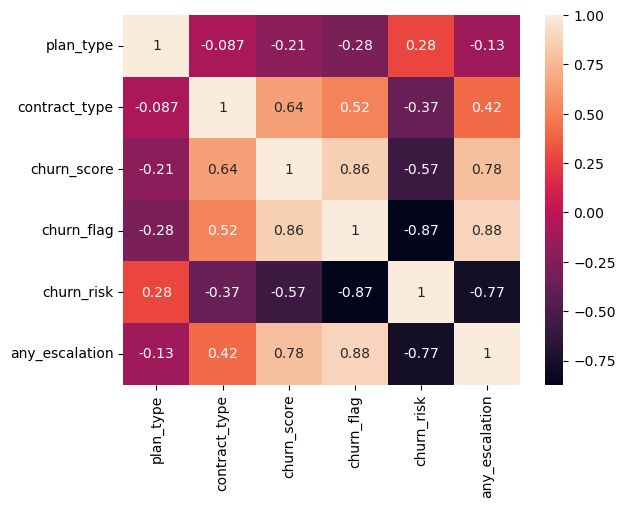

In [76]:
sns.heatmap(df_encoded.corr(),annot=True)

In [77]:
#Correct method of encoding - based on priority
df_encoded = df_visuals[['plan_type', 'contract_type','churn_score', 'churn_flag','churn_risk','any_escalation']]

order_mappings = {
    'plan_type' : ['Basic','Standard','Premium'],
    'contract_type' : ['Monthly','Annual'],
    'churn_risk' : ['Low','Medium','High']
}

for col,order in order_mappings.items():
  df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

In [78]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,any_escalation
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


In [79]:
df_visuals[['plan_type', 'contract_type','churn_score',
       'churn_flag', 'churn_risk', 'any_escalation']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,any_escalation
0,Standard,Annual,12,0,Low,0
1,Premium,Annual,91,1,High,1
2,Basic,Monthly,34,0,Low,0
3,Premium,Annual,8,0,Low,0
4,Standard,Monthly,88,1,High,1


<Axes: >

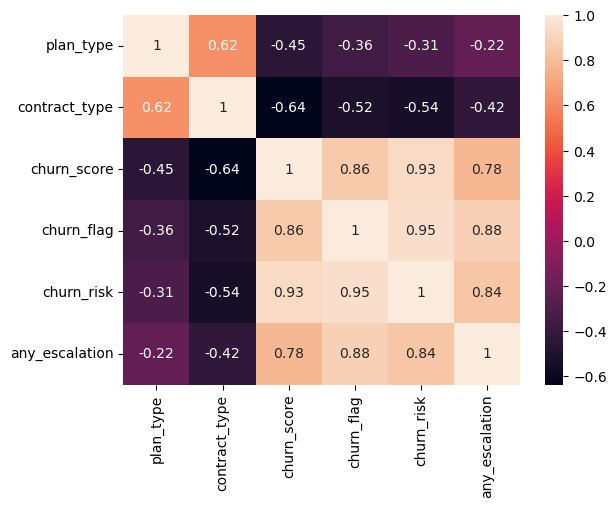

In [80]:
#Heatmap
sns.heatmap(df_encoded.corr(),annot=True)

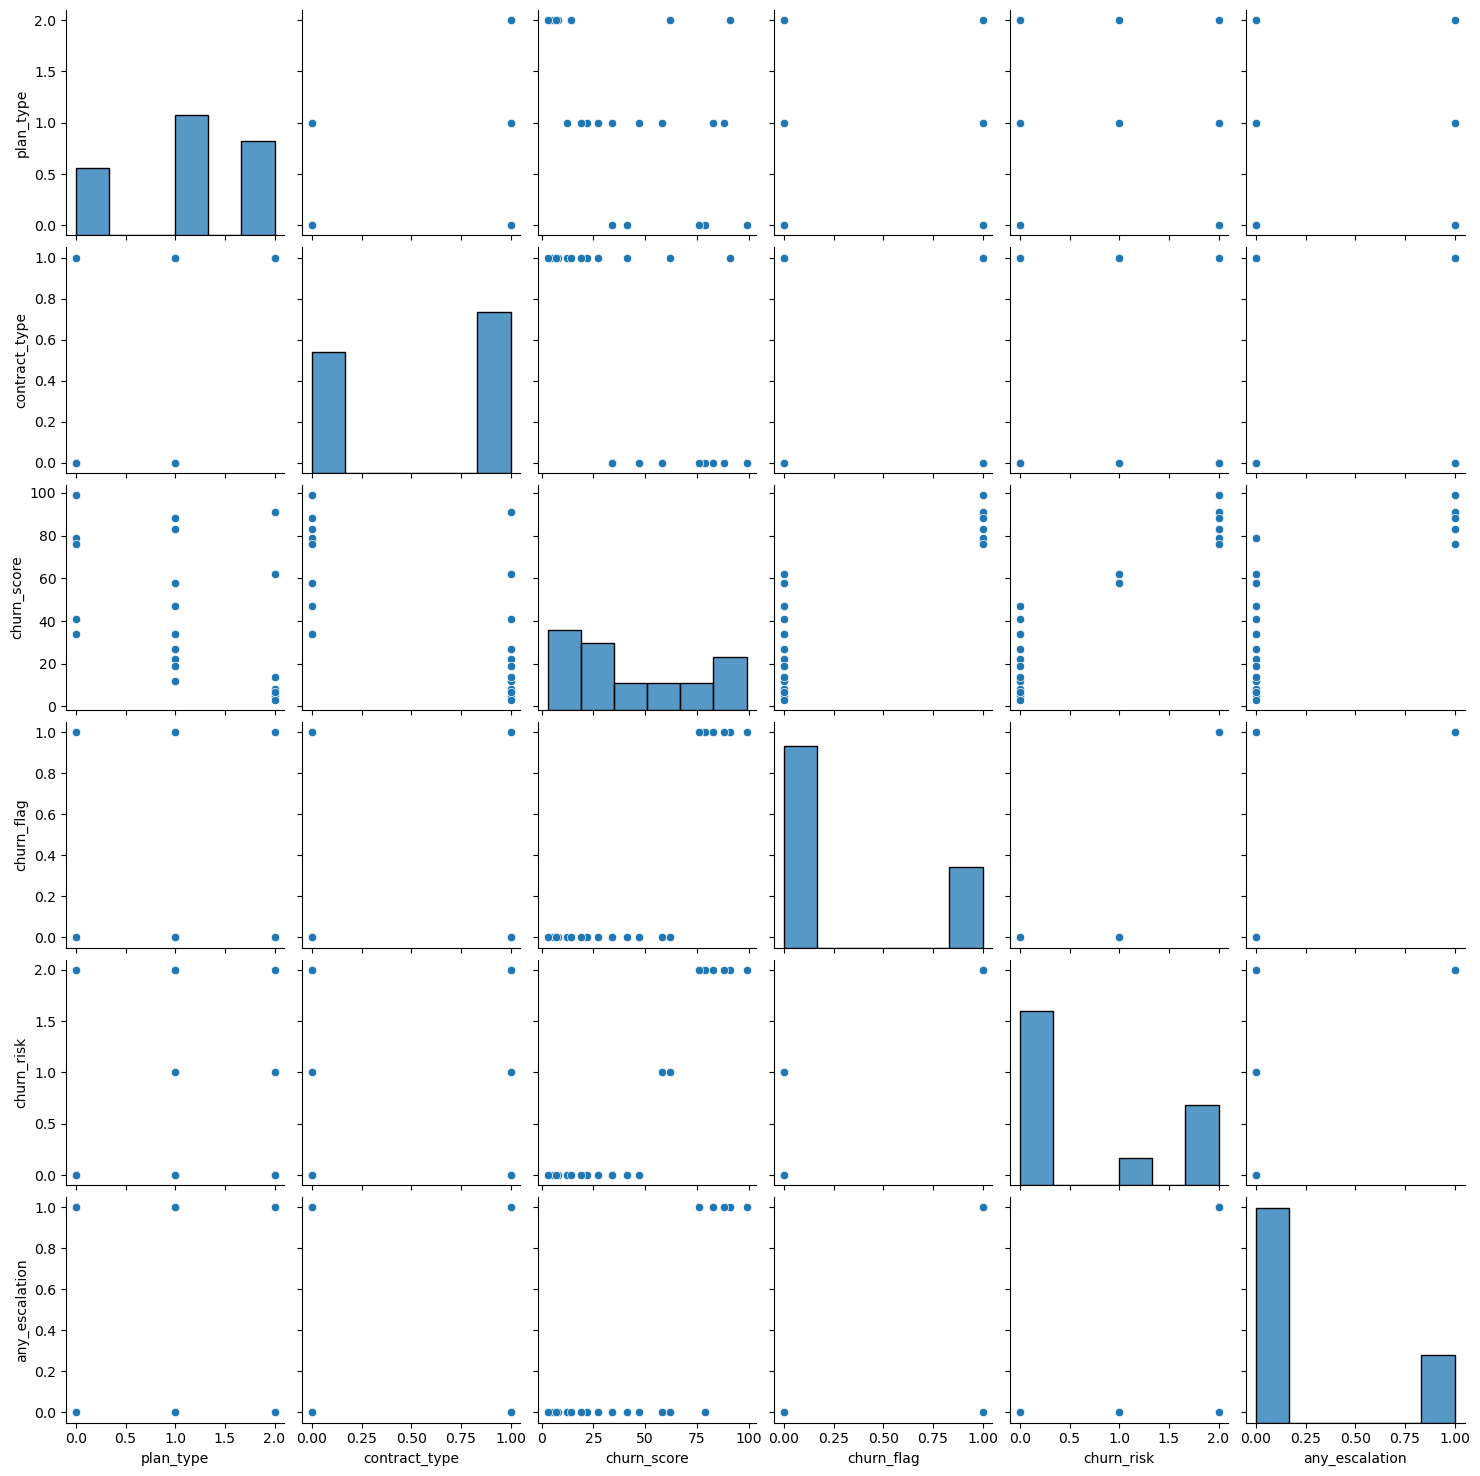

In [81]:
#pairplot - relationship in a dataset
sns.pairplot(df_encoded)

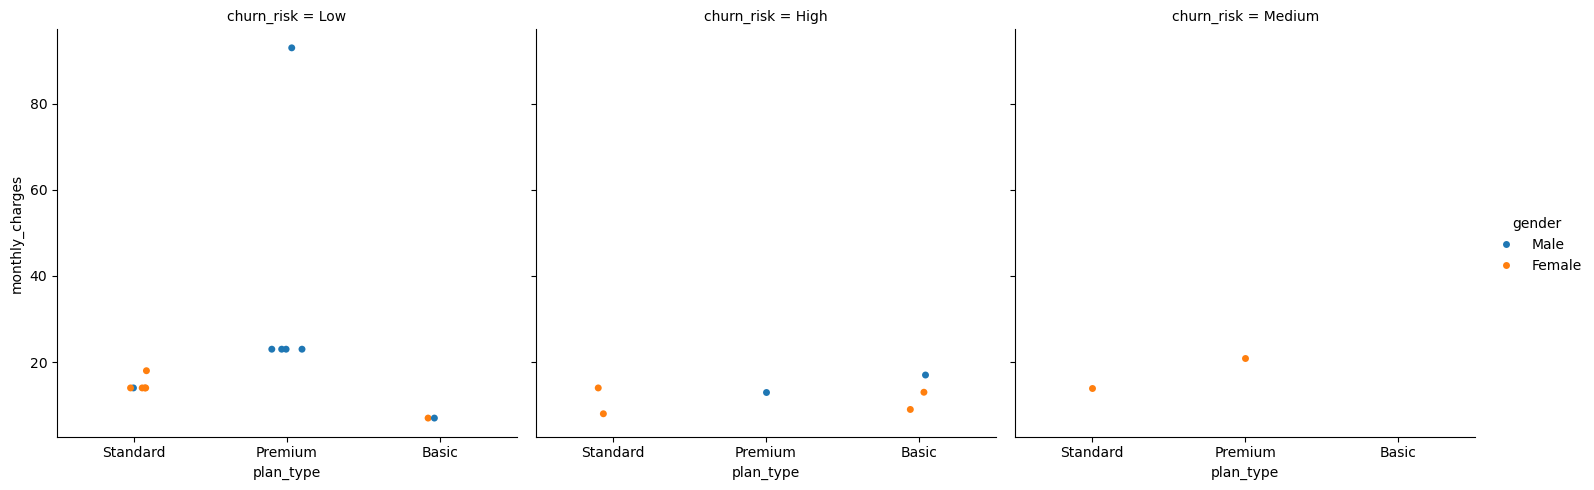

In [82]:
#catplot/facegrid plot - multi-dim comparison

sns.catplot(data=df_visuals,
            x='plan_type',
            y='monthly_charges',
            hue='gender',
            col='churn_risk')

In [83]:
import sqlite3, pandas as pd
conn = sqlite3.connect("customer_churn.db")

In [84]:
# 1) Overall churn rate

q1 = """
SELECT 
    COUNT(*) AS total_customers,
    SUM(CASE WHEN cancellation_date IS NOT NULL THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(100.0 * SUM(CASE WHEN cancellation_date IS NOT NULL THEN 1 ELSE 0 END) / COUNT(*), 1) AS churn_rate_pct
FROM db_subscription;
"""
pd.read_sql(q1, conn)

,total_customers,churned_customers,churn_rate_pct
0,21,6,28.6


In [85]:
# 2) Churn rate by contract_type

q2 = """
SELECT 
    contract_type,
    COUNT(*) AS total,
    SUM(CASE WHEN cancellation_date IS NOT NULL THEN 1 ELSE 0 END) AS churned,
    ROUND(100.0 * SUM(CASE WHEN cancellation_date IS NOT NULL THEN 1 ELSE 0 END) / COUNT(*), 1) AS churn_rate_pct
FROM db_subscription
GROUP BY contract_type;
"""
pd.read_sql(q2, conn)

,contract_type,total,churned,churn_rate_pct
0,Annual,12,1,8.3
1,Monthly,9,5,55.6


In [86]:
# 3) Churn rate by plan_type

q3 = """
SELECT 
    plan_type,
    COUNT(*) AS total,
    SUM(CASE WHEN cancellation_date IS NOT NULL THEN 1 ELSE 0 END) AS churned,
    ROUND(100.0 * SUM(CASE WHEN cancellation_date IS NOT NULL THEN 1 ELSE 0 END) / COUNT(*), 1) AS churn_rate_pct
FROM db_subscription
GROUP BY plan_type;
"""
pd.read_sql(q3, conn)

,plan_type,total,churned,churn_rate_pct
0,Basic,5,3,60.0
1,Premium,7,1,14.3
2,Standard,9,2,22.2


In [87]:
# 4) Churn by tenure bucket

q4 = """
SELECT
    CASE 
        WHEN tenure_days <= 90 THEN '0-90 days'
        WHEN tenure_days <= 365 THEN '90-365 days'
        WHEN tenure_days <= 730 THEN '1-2 years'
        ELSE '2+ years'
    END AS tenure_bucket,
    COUNT(*) AS total,
    SUM(churn) AS churned,
    ROUND(100.0 * SUM(churn) / COUNT(*), 1) AS churn_rate_pct,
    MIN(tenure_days) AS sort_key
FROM (
    SELECT
        customerid,
        CASE WHEN cancellation_date IS NOT NULL THEN 1 ELSE 0 END AS churn,
        julianday(COALESCE(cancellation_date, '2026-09-20')) - julianday(subscription_start_date) AS tenure_days
    FROM db_subscription
)
GROUP BY tenure_bucket
ORDER BY sort_key;
"""
pd.read_sql(q4, conn)

,tenure_bucket,total,churned,churn_rate_pct,sort_key
0,1-2 years,3,3,100.0,366.0
1,2+ years,18,3,16.7,798.0


In [88]:
# 5) 5. Churn rate: has a ticket vs. no ticket

q5 = """
SELECT
    CASE WHEN t.customerid IS NULL THEN 'No ticket' ELSE 'Has ticket' END AS ticket_status,
    COUNT(*) AS total,
    SUM(CASE WHEN s.cancellation_date IS NOT NULL THEN 1 ELSE 0 END) AS churned,
    ROUND(100.0 * SUM(CASE WHEN s.cancellation_date IS NOT NULL THEN 1 ELSE 0 END) / COUNT(*), 1) AS churn_rate_pct
FROM db_subscription s
LEFT JOIN (SELECT DISTINCT customerid FROM db_support) t
    ON s.customerid = t.customerid
GROUP BY ticket_status;
"""
pd.read_sql(q5, conn)

,ticket_status,total,churned,churn_rate_pct
0,Has ticket,7,6,85.7
1,No ticket,14,0,0.0


In [89]:
# 6) CTE — per-customer ticket count + escalation history

q6 = """
WITH support_agg AS (
    SELECT 
        customerid,
        COUNT(*) AS ticket_count,
        MAX(CASE WHEN escalations = 'Y' THEN 1 ELSE 0 END) AS any_escalation,
        MIN(csat_score) AS min_csat
    FROM db_support
    GROUP BY customerid
)
SELECT 
    s.customerid,
    s.contract_type,
    s.plan_type,
    CASE WHEN s.cancellation_date IS NOT NULL THEN 1 ELSE 0 END AS churn,
    COALESCE(sa.ticket_count, 0) AS ticket_count,
    COALESCE(sa.any_escalation, 0) AS any_escalation,
    sa.min_csat
FROM db_subscription s
LEFT JOIN support_agg sa ON s.customerid = sa.customerid;
"""
pd.read_sql(q6, conn)

,customerid,contract_type,plan_type,churn,ticket_count,any_escalation,min_csat
0,0002-ORFBO,Annual,Standard,0,0,0,NaN
1,0003-MKNFE,Annual,Premium,1,2,1,10.0
2,0004-TLHLJ,Monthly,Basic,0,0,0,NaN
3,0011-IGKFF,Annual,Premium,0,0,0,NaN
4,0013-EXCHZ,Monthly,Standard,1,1,1,20.0
5,0013-MHZWF,Annual,Standard,0,1,0,90.0
6,0013-SMEOE,Monthly,Basic,1,1,0,30.0
7,0014-BMAQU,Annual,Premium,0,0,0,NaN
8,0015-UOCOJ,Monthly,Standard,0,0,0,NaN
9,0016-QLJIS,Annual,Basic,0,0,0,NaN


In [90]:
# 7) Revenue and CLTV at risk by plan_type

q7 = """
SELECT
    plan_type,
    ROUND(SUM(CASE WHEN cancellation_date IS NOT NULL THEN monthly_charges ELSE 0 END), 2) AS monthly_revenue_at_risk,
    ROUND(SUM(monthly_charges), 2) AS total_monthly_revenue,
    ROUND(SUM(CASE WHEN cancellation_date IS NOT NULL THEN cltv ELSE 0 END), 2) AS cltv_at_risk,
    ROUND(SUM(cltv), 2) AS total_cltv
FROM db_subscription
GROUP BY plan_type;
"""
pd.read_sql(q7, conn)

,plan_type,monthly_revenue_at_risk,total_monthly_revenue,cltv_at_risk,total_cltv
0,Basic,38.97,52.95,432.0,977.0
1,Premium,12.99,218.93,1150.0,11015.0
2,Standard,21.98,123.91,465.0,5302.0


In [91]:
# 8) Window function — rank customers by CLTV within plan_type

q8 = """
SELECT
    customerid,
    plan_type,
    cltv,
    RANK() OVER (PARTITION BY plan_type ORDER BY cltv DESC) AS cltv_rank_in_plan
FROM db_subscription
ORDER BY plan_type, cltv_rank_in_plan;
"""
pd.read_sql(q8, conn)

,customerid,plan_type,cltv,cltv_rank_in_plan
0,0016-QLJIS,Basic,335,1
1,0013-SMEOE,Basic,230,2
2,0004-TLHLJ,Basic,210,3
3,0019-EFAEP,Basic,160,4
4,0022-TCJCI,Basic,42,5
5,0019-GFNTW,Premium,2185,1
6,0023-HGHWL,Premium,1955,2
7,0014-BMAQU,Premium,1840,3
8,0011-IGKFF,Premium,1725,4
9,0017-DINOC,Premium,1610,5


In [92]:
# 9) HAVING — plan tiers with churn above overall average

q9 = """
SELECT
    plan_type,
    COUNT(*) AS total,
    SUM(CASE WHEN cancellation_date IS NOT NULL THEN 1 ELSE 0 END) AS churned,
    ROUND(100.0 * SUM(CASE WHEN cancellation_date IS NOT NULL THEN 1 ELSE 0 END) / COUNT(*), 1) AS churn_rate_pct
FROM db_subscription
GROUP BY plan_type
HAVING churn_rate_pct > (
    SELECT ROUND(100.0 * SUM(CASE WHEN cancellation_date IS NOT NULL THEN 1 ELSE 0 END) / COUNT(*), 1)
    FROM db_subscription
);
"""
pd.read_sql(q9, conn)

,plan_type,total,churned,churn_rate_pct
0,Basic,5,3,60.0


In [93]:
# Testing whether churn and contract_type are statistically related (not just different by chance)
from scipy.stats import chi2_contingency

ct1 = pd.crosstab(df['contract_type'], df['churn_flag'])
print(ct1)

chi2_1, p1, dof1, expected1 = chi2_contingency(ct1)
print('\nChurn vs Contract Type — chi2:', round(chi2_1,2), ' p-value:', round(p1,4))

churn_flag      0  1
contract_type       
Annual         11  1
Monthly         4  5

Churn vs Contract Type — chi2: 3.54  p-value: 0.0598


In [94]:
# Testing whether churn and escalation history are statistically related
ct2 = pd.crosstab(df['any_escalation'], df['churn_flag'])
print(ct2)

chi2_2, p2, dof2, expected2 = chi2_contingency(ct2)
print('\nChurn vs Escalation — chi2:', round(chi2_2,2), ' p-value:', round(p2,4))

churn_flag       0  1
any_escalation       
0               15  1
1                0  5

Churn vs Escalation — chi2: 12.13  p-value: 0.0005


In [95]:
# Testing whether tenure differs between churned and retained customers
# (Mann-Whitney instead of t-test — doesn't assume normal distribution, safer at n=21)
from scipy.stats import mannwhitneyu

churned_tenure = df[df['churn_flag']==1]['tenure_days']
retained_tenure = df[df['churn_flag']==0]['tenure_days']

stat1, p_tenure = mannwhitneyu(churned_tenure, retained_tenure)
print('Tenure — Mann-Whitney U statistic:', round(stat1,2), ' p-value:', round(p_tenure,4))

Tenure — Mann-Whitney U statistic: 4.0  p-value: 0.0004


In [96]:
# Testing whether CLTV differs between churned and retained customers
churned_cltv = df[df['churn_flag']==1]['cltv']
retained_cltv = df[df['churn_flag']==0]['cltv']

stat2, p_cltv = mannwhitneyu(churned_cltv, retained_cltv)
print('CLTV — Mann-Whitney U statistic:', round(stat2,2), ' p-value:', round(p_cltv,4))

CLTV — Mann-Whitney U statistic: 13.0  p-value: 0.011
